In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("seattle_filtered.csv")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,6606,https://www.airbnb.com/rooms/6606,20250925032813,2025-09-25,city scrape,"Fab, private seattle urban cottage!","This tiny cottage is only 15x10, but it has ev...","A peaceful yet highly accessible neighborhood,...",https://a0.muscache.com/pictures/45742/21116d7...,14942,...,4.77,4.88,4.57,str-opli-19-002622,f,3,3,0,0,0.82
1,9419,https://www.airbnb.com/rooms/9419,20250925032813,2025-09-25,city scrape,Glorious sun room w/ memory foambed,This beautiful double room features sun filled...,"Lots of restaurants (see our guide book) bars,...",https://a0.muscache.com/pictures/56645186/e5fb...,30559,...,4.89,4.70,4.69,Exempt,f,10,0,10,0,1.19
2,11012,https://www.airbnb.com/rooms/11012,20250925032813,2025-09-25,city scrape,"the orange house, quiet 'n central",0,0,https://a0.muscache.com/pictures/682034/54bc27...,14942,...,4.72,4.86,4.74,str-opli-19-002622,f,3,3,0,0,0.51
3,25002,https://www.airbnb.com/rooms/25002,20250925032813,2025-09-25,city scrape,Beautiful Private Spot in North Ballard,"-Great eating , Delancey, Fat Hen, 3 blocks aw...",Great walking neighborhood! We are in between...,https://a0.muscache.com/pictures/491561/cf5270...,102684,...,4.98,4.90,4.90,STR-OPLI-19-002617,t,1,1,0,0,6.06
4,26795,https://www.airbnb.com/rooms/26795,20250925032813,2025-09-25,city scrape,Lake Union Cottage - Shore and City View,"This sunny, corner lot is directly across from...",This area of the Eastlake Neighborhood is quie...,https://a0.muscache.com/pictures/179416/54927c...,114228,...,4.58,4.83,4.36,0,f,1,1,0,0,0.35


In [3]:
bool_map = {
    't': True,
    'f': False
}

df['host_identity_verified'] = df['host_identity_verified'].str.lower().map(bool_map).fillna(False)

C:\Users\annac\AppData\Local\Temp\ipykernel_13612\2351905770.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['host_identity_verified'] = df['host_identity_verified'].str.lower().map(bool_map).fillna(False)


In [4]:
group_cols = ["bedrooms", "bathrooms", "neighbourhood_group_cleansed", "room_type"]

df["avg_price_group"] = df.groupby(group_cols)["price"].transform("mean")

df["relative_price"] = df["price"] / df["avg_price_group"]

In [5]:
df["Is_Long_term"] = (df["minimum_nights"] > 7).astype(int)

df["recent_Review_proportion"] = df["number_of_reviews_ltm"] / df["number_of_reviews"]

### Feature Selection
1) relative_price<br>
(price / average pricing) of listings with same conditions (same neighborhood, # of bedrooms and bathrooms, and roomtype)
2) Housing Characteristics:
    - room_type 
    - bedrooms
    - bathrooms
    - beds
    - accommodates
    - Is_Long_term: 1 if minimum_nights > 7, 0 if minimum_nights <= 7
3) Host Characteristics:
    - host_response_time
    - host_identity_verified
4) Other Users Experience/Engagement:
    - number_of_reviews
    - recent_Review_proportion : number_of_reviews_ltm / number_of_reviews
    - estimated_occupancy_l365d

In [6]:
df_relevant = df[['review_scores_rating',
                  'relative_price', 
                  'room_type', 
                  'bedrooms', 
                  'bathrooms', 
                  'beds', 
                  'accommodates', 
                  'Is_Long_term', 
                  'host_response_time', 
                  'host_identity_verified', 
                  'number_of_reviews', 
                  'recent_Review_proportion', 
                  'estimated_occupancy_l365d']].copy()

In [7]:
df_relevant

,review_scores_rating,relative_price,room_type,bedrooms,bathrooms,beds,accommodates,Is_Long_term,host_response_time,host_identity_verified,number_of_reviews,recent_Review_proportion,estimated_occupancy_l365d
0,4.60,0.796915,Entire home/apt,1.0,1.0,1.0,1,1,within a few hours,True,161,0.000000,0
1,4.73,1.080875,Private room,1.0,3.0,2.0,2,0,within an hour,True,220,0.063636,84
2,4.79,1.279835,Entire home/apt,3.0,2.0,3.0,8,1,within a few hours,True,98,0.000000,0
3,4.93,0.649904,Entire home/apt,1.0,1.0,2.0,4,0,within an hour,True,1139,0.054434,255
4,4.54,0.648780,Entire home/apt,2.0,1.0,3.0,3,1,within a few hours,True,64,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6067,0.00,0.923300,Private room,1.0,1.5,1.0,2,0,0,True,0,NaN,0
6068,0.00,0.923300,Private room,1.0,1.5,1.0,2,0,0,True,0,NaN,0
6069,0.00,1.137554,Private room,1.0,1.0,1.0,2,0,within a few hours,False,0,NaN,0
6070,0.00,0.881646,Entire home/apt,1.0,1.0,1.0,2,1,0,False,0,NaN,0


In [8]:
df_relevant = df_relevant.dropna()
df_relevant.shape

(5364, 13)

In [9]:
threshold = df_relevant['review_scores_rating'].median()
threshold

4.9

In [10]:
y = df_relevant["review_scores_rating"]
y = (y >= threshold).astype(int)

In [11]:
X = df_relevant.drop(columns=["review_scores_rating"])
X = pd.get_dummies(X, drop_first=True)
X

,relative_price,bedrooms,bathrooms,beds,accommodates,Is_Long_term,host_identity_verified,number_of_reviews,recent_Review_proportion,estimated_occupancy_l365d,room_type_Private room,room_type_Shared room,host_response_time_a few days or more,host_response_time_within a day,host_response_time_within a few hours,host_response_time_within an hour
0,0.796915,1.0,1.0,1.0,1,1,True,161,0.000000,0,False,False,False,False,True,False
1,1.080875,1.0,3.0,2.0,2,0,True,220,0.063636,84,True,False,False,False,False,True
2,1.279835,3.0,2.0,3.0,8,1,True,98,0.000000,0,False,False,False,False,True,False
3,0.649904,1.0,1.0,2.0,4,0,True,1139,0.054434,255,False,False,False,False,False,True
4,0.648780,2.0,1.0,3.0,3,1,True,64,0.000000,0,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6004,0.765822,1.0,1.0,1.0,2,0,True,3,1.000000,18,False,False,False,False,False,True
6007,0.594006,3.0,3.5,3.0,6,0,False,2,1.000000,12,False,False,False,False,False,True
6018,1.260954,2.0,2.0,2.0,4,0,True,1,1.000000,6,False,False,False,False,False,True
6026,0.982057,1.0,1.0,2.0,3,0,True,3,1.000000,18,False,False,False,False,False,True


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
#  Train Gradient Boosting Model

model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [14]:
y_pred = model.predict(X_test)

In [15]:
#  Evaluate model

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6290773532152842

Confusion Matrix:
[[278 245]
 [153 397]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.53      0.58       523
           1       0.62      0.72      0.67       550

    accuracy                           0.63      1073
   macro avg       0.63      0.63      0.62      1073
weighted avg       0.63      0.63      0.63      1073



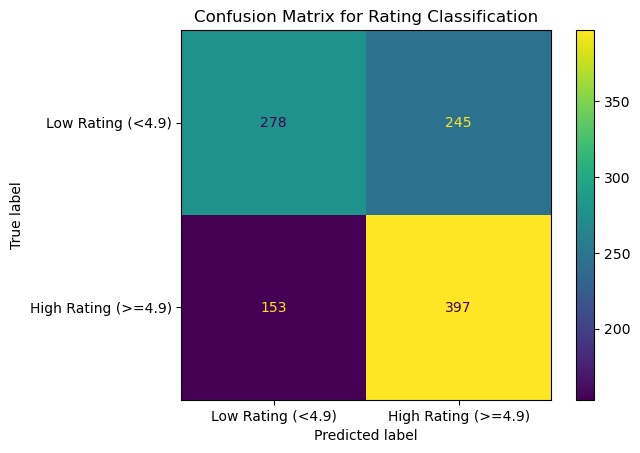

In [16]:
#  Plot confusion matrix
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=["Low Rating (<4.9)", "High Rating (>=4.9)"]
)

plt.title("Confusion Matrix for Rating Classification")
plt.show()

In [17]:
#  Feature importance

importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop Important Features:")
print(importance_df.head(10))


Top Important Features:
                                  Feature  Importance
0                          relative_price    0.261662
7                       number_of_reviews    0.186509
8                recent_Review_proportion    0.145314
9               estimated_occupancy_l365d    0.117666
10                 room_type_Private room    0.080867
2                               bathrooms    0.063754
1                                bedrooms    0.060194
4                            accommodates    0.026330
14  host_response_time_within a few hours    0.018182
15      host_response_time_within an hour    0.014333


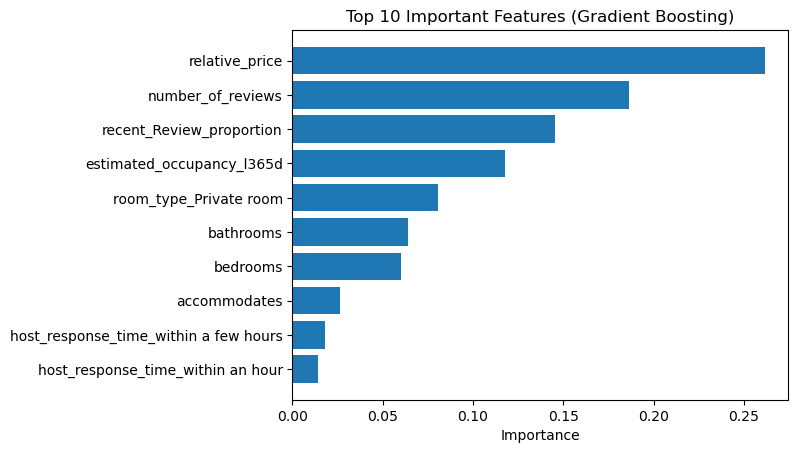

In [18]:
#  Plot feature importance

top_features = importance_df.head(10)

plt.figure()
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Important Features (Gradient Boosting)")
plt.show()